## HR Employee Attrition Analysis and Prediction

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


## Load Dataset

In [4]:
df = pd.read_csv("C:/Users/mezan/OneDrive/Documents/Data_Science/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Overview

In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## Missing Values Analysis

In [11]:
df.isnull().sum()     # There is no missing values bcz "all columns = 0"  because there is nothing to fill.

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Data Cleaning

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning Summary
Checked for missing values using df.isnull().sum().
No missing values were found in the dataset.
Checked for duplicate records using df.duplicated().sum().
No duplicate records were found.
Removed irrelevant columns that do not contribute to employee attrition prediction.

## Remove unnecessary columns

In [14]:
drop_cols=["BusinessTravel","DailyRate","Education","EducationField","EmployeeCount","EmployeeNumber",
           "HourlyRate","MonthlyRate","NumCompaniesWorked","Over18","PerformanceRating",
           "RelationshipSatisfaction","StandardHours","StockOptionLevel","TrainingTimesLastYear",
           "YearsWithCurrManager"]
df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [15]:
print(df.shape)

(1470, 19)


## Exploratory Data Analysis

### Attrition Distribution

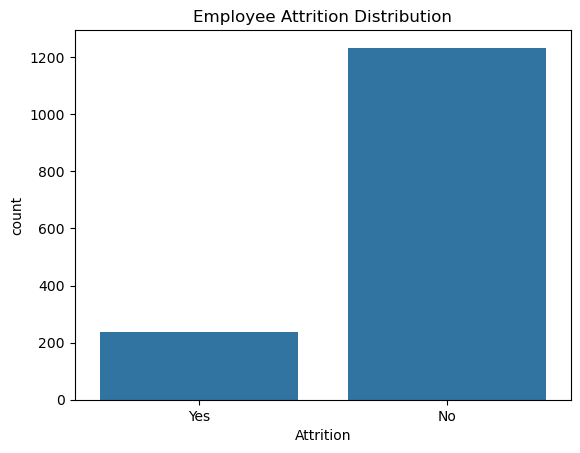

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [16]:
sns.countplot(x='Attrition', data=df)

plt.title("Employee Attrition Distribution")
plt.show()

(df['Attrition'].value_counts(normalize=True) * 100).round(2)

## Overtime vs Attrition

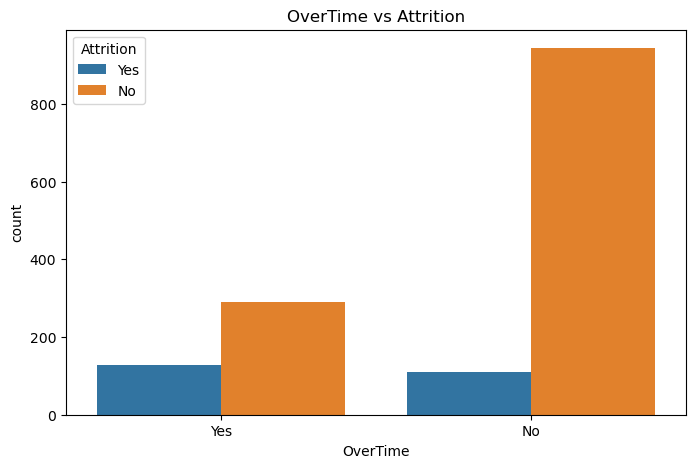

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("OverTime vs Attrition")
plt.show()

# pd.crosstab(df['OverTime'], df['Attrition'])
(pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100).round(2)

## Job Satisfaction vs Attrition

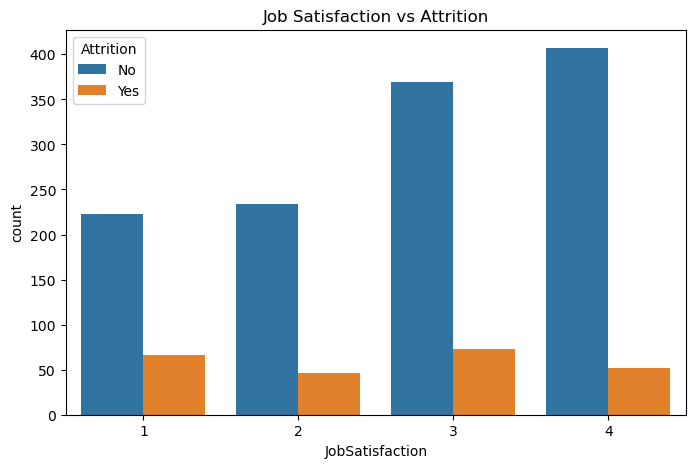

Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)

plt.title("Job Satisfaction vs Attrition")
plt.show()

(pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100).round(2)

## Work-Life Balance vs Attrition

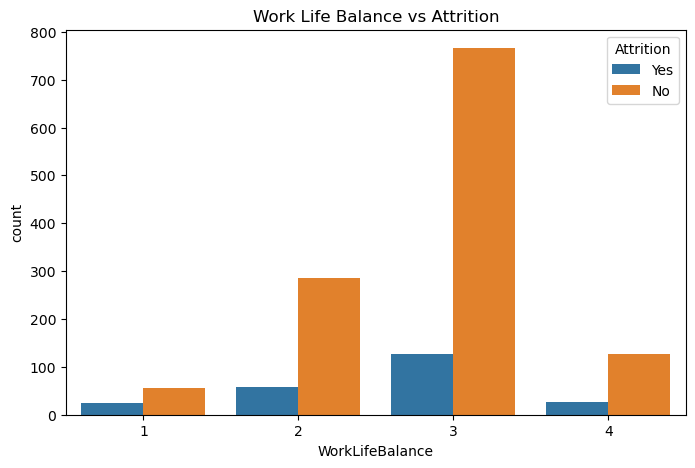

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)

plt.title("Work Life Balance vs Attrition")
plt.show()

(pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100).round(2)

## Department vs Attrition

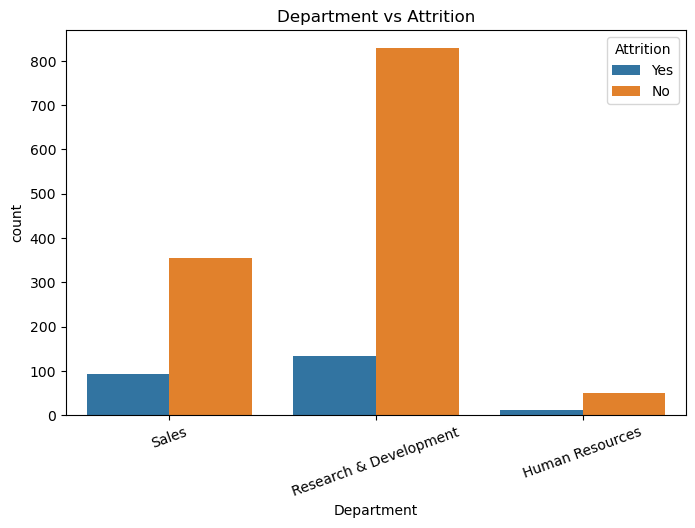

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=20)

plt.title("Department vs Attrition")
plt.show()

(pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100).round(2)

## Monthly Income vs Attrition

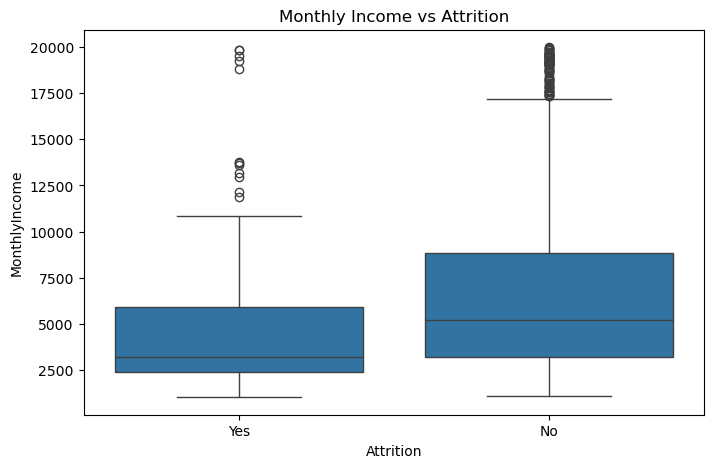

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title("Monthly Income vs Attrition")
plt.show()


## Age Distribution

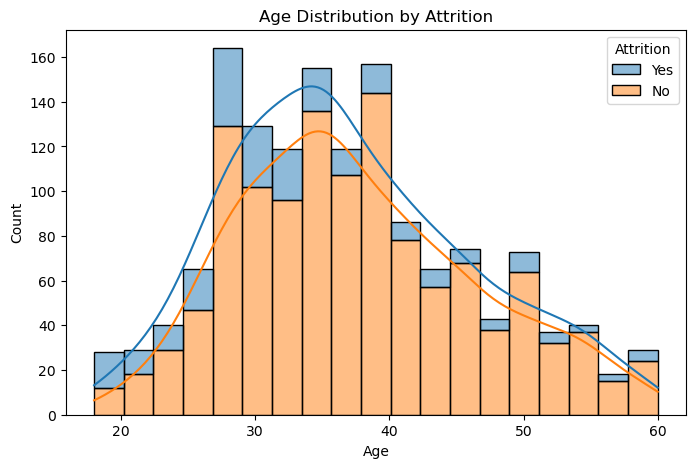

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    kde=True,
    multiple='stack'
)

plt.title("Age Distribution by Attrition")
plt.show()

## Correlation Heatmap

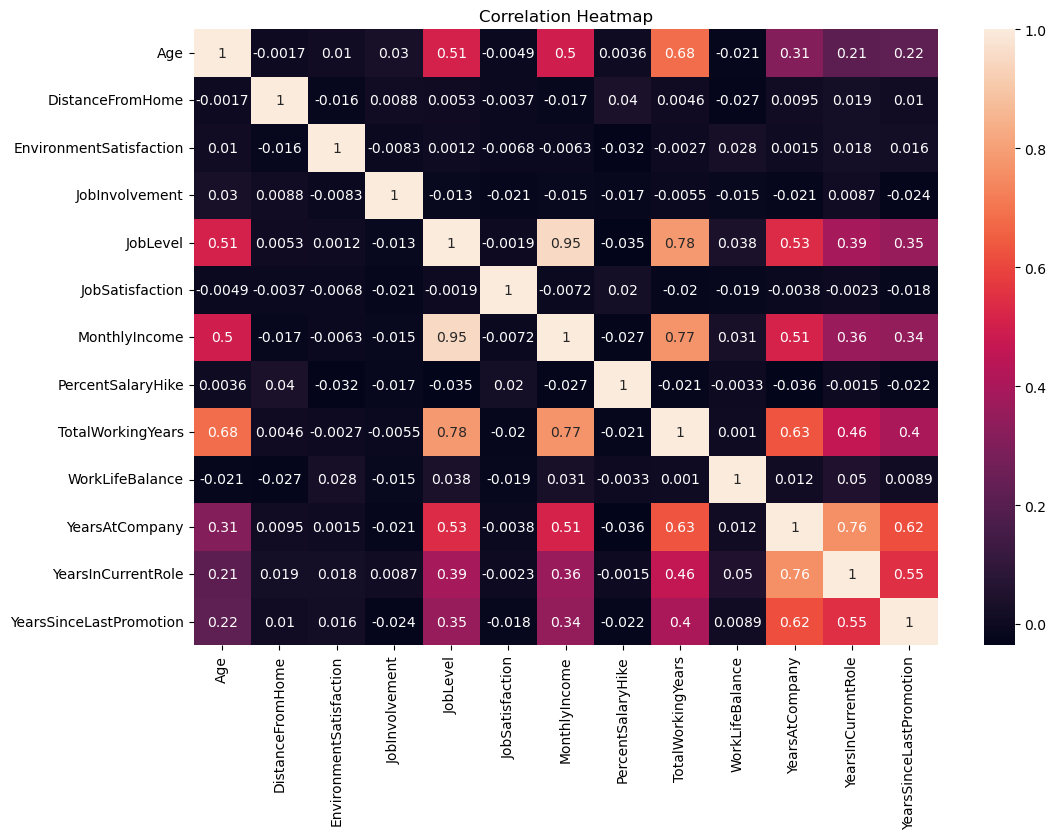

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Machine Learning Model Building

In [24]:
df.select_dtypes(include='object').columns   # Categorical columns check

Index(['Attrition', 'Department', 'Gender', 'JobRole', 'MaritalStatus',
       'OverTime'],
      dtype='object')

In [25]:
# Step 1: Convert categorical variables into numeric dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(1470, 28)


,Age,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,2,3,2,4,5993,11,8,1,...,False,False,False,False,False,True,False,False,True,True
1,49,8,3,2,2,2,5130,23,10,3,...,False,False,False,False,True,False,False,True,False,False
2,37,2,4,2,1,3,2090,15,7,3,...,True,False,False,False,False,False,False,False,True,True
3,33,3,4,3,1,3,2909,11,8,3,...,False,False,False,False,True,False,False,True,False,True
4,27,2,1,3,1,2,3468,12,6,3,...,True,False,False,False,False,False,False,True,False,False


## Feature Selection

# Feature Selection

## Objective

Machine Learning models require two components:

- Features (X): Employee information used for prediction.
- Target Variable (y): The value we want to predict.

In this project:

- Features (X) contain employee-related information.
- Target Variable (y) is **Attrition_Yes**, where:
    - 1 = Employee Left
    - 0 = Employee Stayed

In [26]:
# Features
X = df_encoded.drop('Attrition_Yes', axis=1)

# Target
y = df_encoded['Attrition_Yes']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1470, 27)
Target Shape : (1470,)


## Train-Test Split

### Why do we split the dataset?

The machine learning model should not be tested using the same data on which it was trained.

Therefore, the dataset is divided into:

- Training Data (80%)
- Testing Data (20%)

The model learns from the training data and is evaluated using the testing data to measure its performance on unseen data.

### Observation

The dataset was split into 80% training data and 20% testing data.

The training data is used to build the machine learning model, while the testing data is used to evaluate how well the model performs on new, unseen data.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1176, 27)
Testing Features : (294, 27)
Training Target : (1176,)
Testing Target : (294,)


## Feature Scaling

### Why Feature Scaling?

Feature Scaling standardizes numerical values so that all features are measured on a similar scale.

This improves the performance of algorithms such as Logistic Regression.

Decision Tree and Random Forest are generally not affected by feature scaling, but scaled data is prepared for consistency.

### Observation

Feature Scaling was applied using StandardScaler.

This ensures that all numerical features are on a comparable scale, improving the performance of Logistic Regression.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data :", X_train_scaled.shape)
print("Scaled Testing Data :", X_test_scaled.shape)

Scaled Training Data : (1176, 27)
Scaled Testing Data : (294, 27)


# Model Building

## 1. Logistic Regression

#### What is Logistic Regression?

Logistic Regression is a supervised machine learning classification algorithm.

It is used when the target variable has only two possible outcomes.

In this project:

- 0 = Employee Stayed
- 1 = Employee Left

The model predicts the probability of whether an employee will leave the organization based on employee-related features.

#### Why Logistic Regression?

Logistic Regression is suitable because employee attrition is a binary classification problem.

It is simple, fast, easy to interpret, and serves as a good baseline model.

In [31]:
# Model Building
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
## Model Prediction

y_pred_log = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8673469387755102


In [34]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[243  12]
 [ 27  12]]


### Confusion Matrix Observation

The model correctly predicted:

- 243 employees who stayed in the company.
- 12 employees who actually left the company.

The model incorrectly predicted:

- 12 employees as leaving when they actually stayed.
- 27 employees as staying when they actually left.

The model performs well in identifying employees who stay but finds it more difficult to identify employees who leave.

In [35]:
# Classification Report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

       False       0.90      0.95      0.93       255
        True       0.50      0.31      0.38        39

    accuracy                           0.87       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.85      0.87      0.85       294



## 2. Decision Tree Classifier

### What is a Decision Tree?

A Decision Tree is a supervised machine learning classification algorithm.

It predicts the target variable by learning a series of decision rules from the training data.

The model splits the dataset into branches based on feature values until it reaches a final prediction.

In this project, the Decision Tree predicts whether an employee is likely to leave the company.

### Why Decision Tree?

Decision Tree is easy to understand and interpret.

It can capture non-linear relationships between employee features and attrition.

Unlike Logistic Regression, it does not require feature scaling.

In [42]:
# Model Building
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
## Model Prediction
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7857142857142857


### Observation

The Decision Tree model achieved an accuracy of **78%**.

This accuracy will be compared with Logistic Regression and Random Forest to determine the best-performing model.

In [44]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[222  33]
 [ 30   9]]


In [45]:
# Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.88      0.87      0.88       255
        True       0.21      0.23      0.22        39

    accuracy                           0.79       294
   macro avg       0.55      0.55      0.55       294
weighted avg       0.79      0.79      0.79       294



## 3. Random Forest Classifier

### What is Random Forest?

Random Forest is an ensemble machine learning algorithm.

Instead of using a single Decision Tree, it creates multiple Decision Trees and combines their predictions.

This usually improves prediction accuracy and reduces overfitting.

### Why Random Forest?

Random Forest generally performs better than a single Decision Tree because it combines predictions from multiple trees.

It is more robust and less likely to overfit the training data.

In [46]:
# Model Building
rf_model = RandomForestClassifier(random_state=42)# random_state=42 --> Fix the random selection so that every time we run the notebook, we get the same result.
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Model Prediction
y_pred_rf = rf_model.predict(X_test)

# Model Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8707482993197279


In [48]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[250   5]
 [ 33   6]]


### Observation

Random Forest combines multiple Decision Trees to improve prediction performance.

The evaluation metrics will be compared with Logistic Regression and Decision Tree to identify the best model.

In [49]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.88      0.98      0.93       255
        True       0.55      0.15      0.24        39

    accuracy                           0.87       294
   macro avg       0.71      0.57      0.58       294
weighted avg       0.84      0.87      0.84       294



# Model Comparison

### Model Comparison Observation

The performance of Logistic Regression, Decision Tree, and Random Forest was compared using accuracy.

The model with the highest accuracy and better classification performance will be selected as the final predictive model for employee attrition.

In [50]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, dt_accuracy, rf_accuracy]
})

comparison.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,0.870748
0,Logistic Regression,0.867347
1,Decision Tree,0.785714


### Model Comparison

The performance of three machine learning algorithms was evaluated using prediction accuracy.

| Model | Accuracy |
|--------|----------|
| Logistic Regression | 86.73% |
| Decision Tree | 78.57% |
| Random Forest | 87.07% |

Random Forest achieved the highest accuracy, followed closely by Logistic Regression.

Decision Tree produced the lowest accuracy among the evaluated models.

# Project Conclusion

The objective of this project was to analyze employee attrition and develop machine learning models capable of predicting whether an employee is likely to leave the organization.

The project followed the complete Data Science lifecycle, including:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Correlation Analysis
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation

Three machine learning algorithms were implemented:

- Logistic Regression
- Decision Tree
- Random Forest

Among these models, Random Forest achieved the highest accuracy of **87.07%**, making it the most effective model for this dataset.

The analysis also identified several important factors associated with employee attrition, including:

- Overtime
- Job Satisfaction
- Work-Life Balance
- Monthly Income
- Age
- Department

These findings can help HR departments identify employees who may be at risk of leaving and support data-driven retention strategies.

# Business Recommendations

Based on the analysis, the following recommendations are suggested:

- Reduce excessive overtime to improve employee well-being.
- Improve employee job satisfaction through recognition and career development.
- Promote a healthy work-life balance.
- Review salary structures to remain competitive.
- Provide additional support and growth opportunities for younger employees.
- Use predictive analytics to identify employees who may be at risk of attrition and take proactive retention measures.

## Save Machine Learning Model

In [52]:
# Joblib is used to save trained Machine Learning models so they can be reused later without training them again.
import joblib

In [53]:
joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [54]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [55]:
import os

os.listdir()

['.ipynb_checkpoints', 'HR_Attrition_Project.ipynb', 'model.pkl', 'scaler.pkl']

In [56]:
df_encoded.drop('Attrition_Yes', axis=1).columns.tolist()

['Age',
 'DistanceFromHome',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'Department_Research & Development',
 'Department_Sales',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'OverTime_Yes']